# Analysis

**Primary outcomes:** P(materially different conclusion) and effect-estimate error.
**Secondary outcomes:** P(valid adjustment set) and SHD.
Error conditions: false positive, wrong direction, and false negative in its clean range (prohibitions of true edges not among the required claims: e ≤ 0.3 at 75% coverage). All results at 75% coverage; intervals are 95% bootstrap intervals over seeds.

## 1. Load results and compute effect error

Effect error for a pair is |estimate − true effect| divided by the standard error of the correctly adjusted estimate; each run's value is the median over its identified pairs.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS, FIGURES = Path("../results"), Path("../figures")
FIGURES.mkdir(exist_ok=True)
COVERAGE = 0.75
ERRORS = ["false_positive", "wrong_direction", "false_negative"]
LABELS = {"false_positive": "False positive", "wrong_direction": "Wrong direction",
          "false_negative": "False negative (unasserted)"}
COLORS = {"false_positive": "#2b6cb0", "wrong_direction": "#2f855a", "false_negative": "#c05621"}
KEYS = ["graph", "n", "seed", "condition", "coverage", "error_type", "e"]

df = pd.read_csv(RESULTS / "graph_metrics.csv")
adj = pd.read_csv(RESULTS / "adjustment.csv")

ref_se = (adj.ref_hi - adj.ref_lo) / (2 * 1.959964)
adj["err_se"] = (adj.est - adj.true_effect).abs() / ref_se
effect = adj.dropna(subset=["err_se"]).groupby(KEYS).err_se.median().rename("effect_error").reset_index()
df = df.merge(effect, on=KEYS, how="left")

GRAPHS, NS = sorted(df.graph.unique()), sorted(df.n.unique())
print(f"{len(df)} runs, {df.seed.nunique()} seeds")

9900 runs, 50 seeds


## 2. Curves

In [7]:
# e = 0 (correct knowledge) is shared by every error type; false negatives kept only for e <= 0.3
correct = df[(df.condition == "correct") & (df.coverage == COVERAGE)]
corrupted = df[(df.condition == "corrupted") & (df.coverage == COVERAGE) & df.error_type.isin(ERRORS)]
curves = pd.concat([corrupted] + [correct.assign(error_type=t) for t in ERRORS], ignore_index=True)
curves = curves[(curves.error_type != "false_negative") | (curves.e <= 0.3 + 1e-9)]
baseline = df[df.condition == "baseline"]

def boot_ci(values, n_boot=2000, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    means = np.random.default_rng(seed).choice(values, (n_boot, len(values))).mean(axis=1)
    return values.mean(), np.percentile(means, 2.5), np.percentile(means, 97.5)

def plot_metric(metric, ylabel, filename, ylim=None, log=False):
    fig, axes = plt.subplots(len(GRAPHS), len(NS), figsize=(4.2 * len(NS), 3.4 * len(GRAPHS)),
                             sharey=True, squeeze=False)
    for i, g in enumerate(GRAPHS):
        for j, n in enumerate(NS):
            ax = axes[i, j]
            for t in ERRORS:
                sub = curves[(curves.graph == g) & (curves.n == n) & (curves.error_type == t)]
                stats = np.array([boot_ci(s[metric]) for _, s in sub.groupby("e")])
                es = sorted(sub.e.unique())
                ax.plot(es, stats[:, 0], marker="o", color=COLORS[t], label=LABELS[t])
                ax.fill_between(es, stats[:, 1], stats[:, 2], color=COLORS[t], alpha=0.18, linewidth=0)
            m, lo, hi = boot_ci(baseline[(baseline.graph == g) & (baseline.n == n)][metric])
            ax.axhline(m, ls="--", color="gray", label="No knowledge")
            ax.axhspan(lo, hi, color="gray", alpha=0.12, linewidth=0)
            ax.set_title(f"{g.replace('_', ' ')}, n = {n}")
            ax.set_xlabel("error rate e")
            if log: ax.set_yscale("log")
            if ylim: ax.set_ylim(*ylim)
            ax.grid(alpha=0.3)
        axes[i, 0].set_ylabel(ylabel)
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=200, bbox_inches="tight")
    plt.show()

## 3. Figures

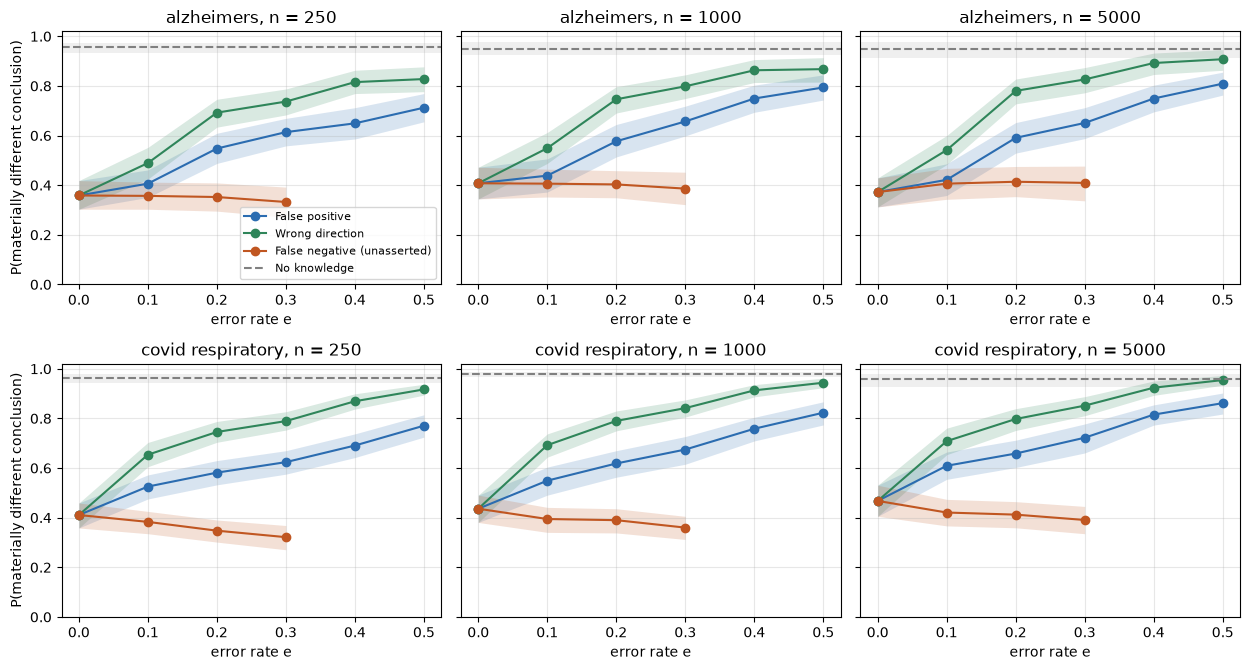

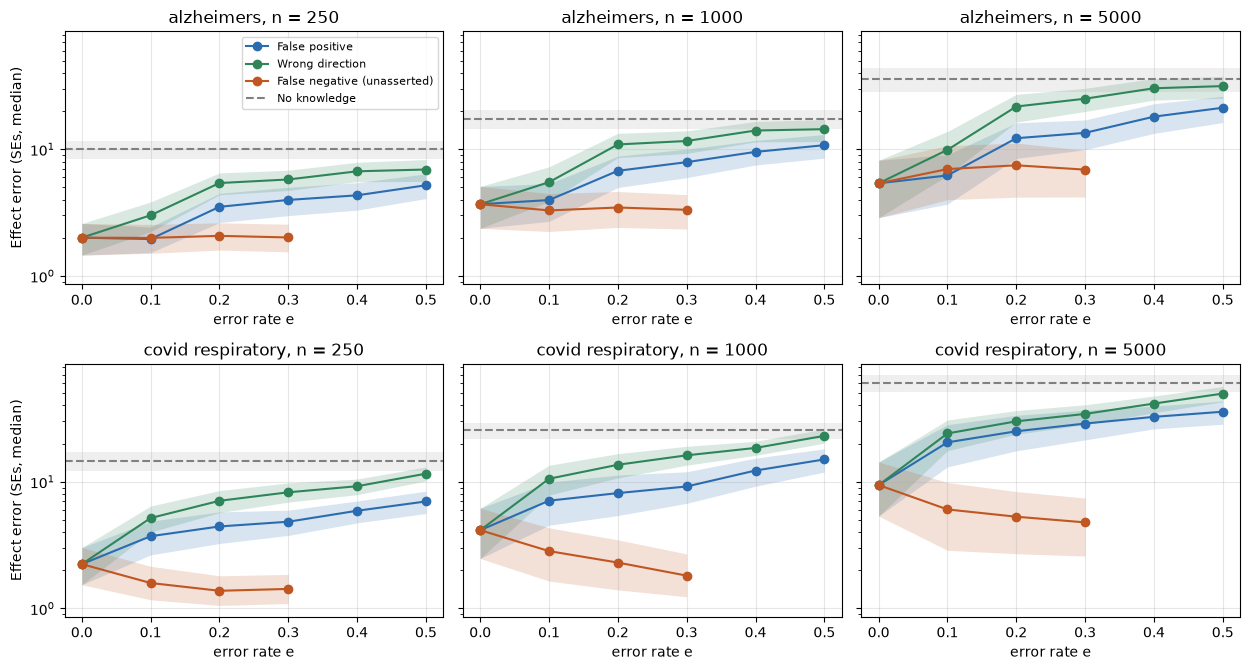

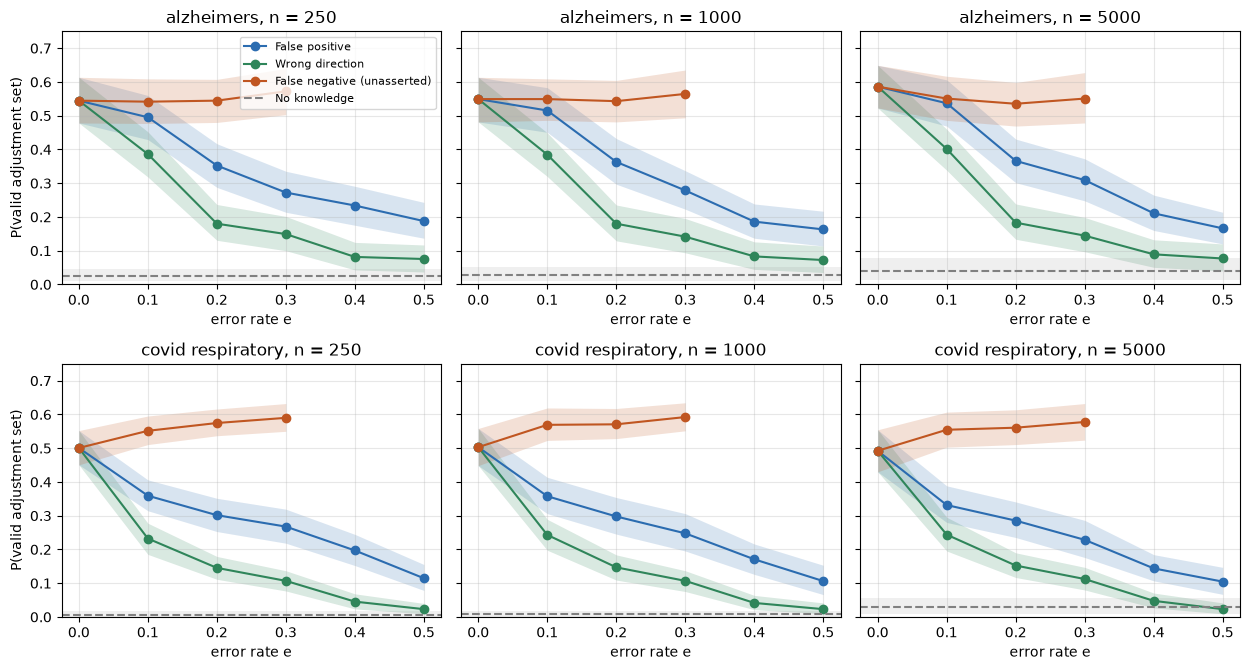

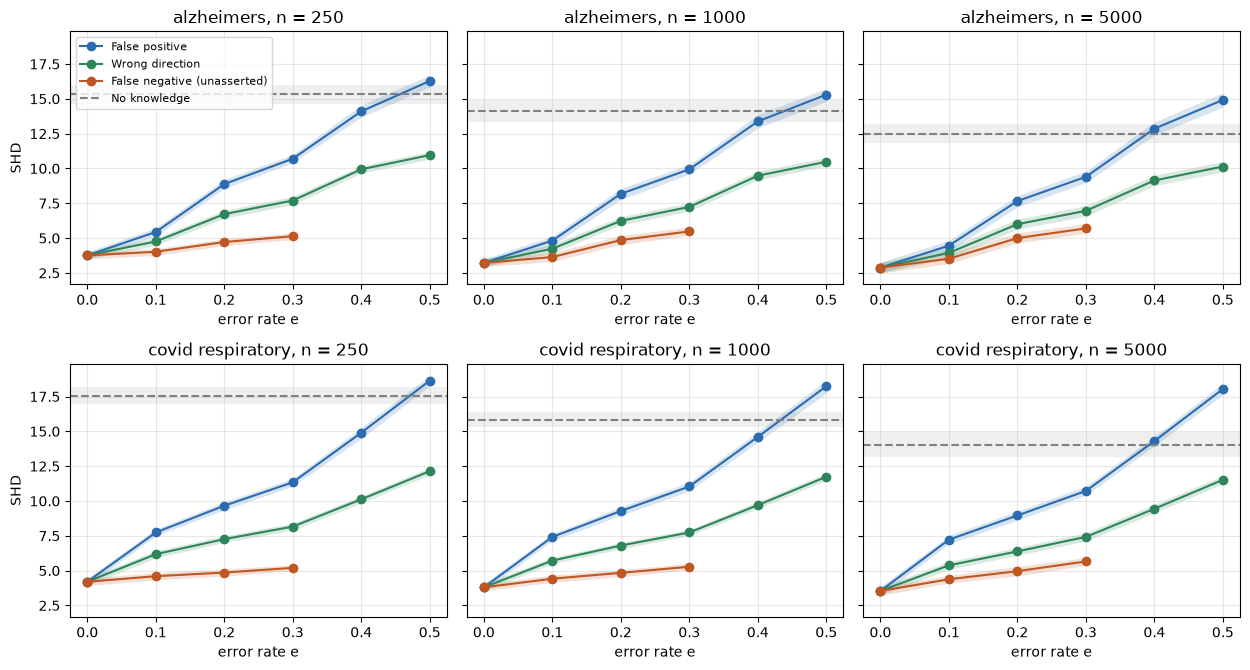

In [8]:
plot_metric("p_material", "P(materially different conclusion)", "fig1_material.png", ylim=(0, 1.02))
plot_metric("effect_error", "Effect error (SEs, median)", "fig2_effect_error.png", log=True)
plot_metric("p_valid", "P(valid adjustment set)", "fig3_validity.png", ylim=(0, 0.75))
plot_metric("shd", "SHD", "fig4_shd.png")

## 4. Key numbers (mean over seeds and sample sizes)

In [9]:
metrics = ["p_material", "effect_error", "p_valid", "shd"]
display(baseline.groupby("graph")[metrics].mean().round(2))
curves.groupby(["graph", "error_type", "e"])[metrics].mean().round(2)

,p_material,effect_error,p_valid,shd
graph,,,,
alzheimers,0.95,21.07,0.03,13.98
covid_respiratory,0.97,33.63,0.01,15.81


p_material  effect_error  p_valid  \
graph             error_type      e                                        
alzheimers        false_negative  0.0        0.38          3.69     0.56   
                                  0.1        0.39          4.09     0.55   
                                  0.2        0.39          4.33     0.54   
                                  0.3        0.38          4.08     0.56   
                  false_positive  0.0        0.38          3.69     0.56   
                                  0.1        0.42          4.05     0.52   
                                  0.2        0.57          7.50     0.36   
                                  0.3        0.64          8.45     0.29   
                                  0.4        0.72         10.65     0.21   
                                  0.5        0.77         12.41     0.17   
                  wrong_direction 0.0        0.38          3.69     0.56   
                                  0.1        0.53          6.14     0.39   
                                  0.2        0.74         12.69     0.18   
                                  0.3        0.79         14.15     0.15   
                                  0.4        0.86         17.02     0.08   
                                  0.5        0.87         17.61     0.07   
covid_respiratory false_negative  0.0        0.44          5.26     0.50   
                                  0.1        0.40          3.49     0.56   
                                  0.2        0.38          2.99     0.57   
                                  0.3        0.36          2.67     0.59   
                  false_positive  0.0        0.44          5.26     0.50   
                                  0.1        0.56         10.42     0.35   
                                  0.2        0.62         12.53     0.29   
                                  0.3        0.67         14.27     0.25   
                                  0.4        0.75         16.90     0.17   
                                  0.5        0.82         19.24     0.11   
                  wrong_direction 0.0        0.44          5.26     0.50   
                                  0.1        0.68         13.27     0.24   
                                  0.2        0.78         16.90     0.15   
                                  0.3        0.83         19.58     0.11   
                                  0.4        0.90         23.04     0.04   
                                  0.5        0.94         28.10     0.02   

                                         shd  
graph             error_type      e           
alzheimers        false_negative  0.0   3.29  
                                  0.1   3.73  
                                  0.2   4.86  
                                  0.3   5.44  
                  false_positive  0.0   3.29  
                                  0.1   4.91  
                                  0.2   8.24  
                                  0.3  10.01  
                                  0.4  13.45  
                                  0.5  15.50  
                  wrong_direction 0.0   3.29  
                                  0.1   4.31  
                                  0.2   6.32  
                                  0.3   7.30  
                                  0.4   9.52  
                                  0.5  10.53  
covid_respiratory false_negative  0.0   3.85  
                                  0.1   4.47  
                                  0.2   4.89  
                                  0.3   5.38  
                  false_positive  0.0   3.85  
                                  0.1   7.46  
                                  0.2   9.30  
                                  0.3  11.03  
                                  0.4  14.60  
                                  0.5  18.31  
                  wrong_direction 0.0   3.85  
                                  0.1   5.76  
                                  0.2   6.81

## 5. How quickly errors change the conclusion (P(material))

- **Error tolerance:** smallest e at which P(material) is significantly higher than with correct knowledge (paired bootstrap over seeds).
- **Half-loss point e₅₀:** e at which P(material) has risen halfway from the correct-knowledge level to the no-knowledge level (linear interpolation; NaN = never within the tested range).

In [10]:
def series(g, n, t, e):
    s = curves[(curves.graph == g) & (curves.n == n) & (curves.error_type == t) & np.isclose(curves.e, e)]
    return s.set_index("seed").p_material

def tolerance(g, n, t):
    es = sorted(curves[curves.error_type == t].e.unique())
    for e in es[1:]:
        if boot_ci((series(g, n, t, e) - series(g, n, t, 0)).dropna())[1] > 0:
            return e
    return f">{es[-1]:.1f}"

def e50(g, n, t):
    c = curves[(curves.graph == g) & (curves.n == n) & (curves.error_type == t)].groupby("e").p_material.mean()
    target = c.iloc[0] + (baseline[(baseline.graph == g) & (baseline.n == n)].p_material.mean() - c.iloc[0]) / 2
    for (e0, v0), (e1, v1) in zip(c.items(), list(c.items())[1:]):
        if v1 >= target:
            return round(e0 + (target - v0) * (e1 - e0) / (v1 - v0), 2)
    return np.nan

thresholds = pd.DataFrame([dict(graph=g, n=n, error_type=t, tolerance=tolerance(g, n, t), e50=e50(g, n, t))
                           for g in GRAPHS for n in NS for t in ERRORS])
thresholds.to_csv(RESULTS / "summary_thresholds.csv", index=False)
display(thresholds.pivot(index=["graph", "n"], columns="error_type", values="tolerance"))
thresholds.pivot(index=["graph", "n"], columns="error_type", values="e50")

error_type             false_negative false_positive wrong_direction
graph             n                                                 
alzheimers        250            >0.3            0.1             0.1
                  1000           >0.3            0.2             0.1
                  5000           >0.3            0.1             0.1
covid_respiratory 250            >0.3            0.1             0.1
                  1000           >0.3            0.1             0.1
                  5000           >0.3            0.1             0.1

error_type              false_negative  false_positive  wrong_direction
graph             n                                                    
alzheimers        250              NaN            0.41             0.18
                  1000             NaN            0.32             0.17
                  5000             NaN            0.31             0.15
covid_respiratory 250              NaN            0.39             0.14
                  1000             NaN            0.34             0.11
                  5000             NaN            0.29             0.11